# Lineare Ausgleichsrechnung

Ziel ist es, die Parameter $\vec{p} \in \mathbb{R}^n$ eines Modells $\vec{f}(p, {\color{gray}X})$ an Messdaten $X$ zu fitten. In der **linearen Ausgleichsrechung** ist die Abhängigkeit von $\vec{p}$ linear. Aufstellen der Gleichungen

$$
    \vec{f}(p, {\color{gray}X}) \stackrel!= \vec{0}
$$

führt auf ein überbestimmtes lineares Gleichungssystem

$$
    A \vec{p} = \vec{y}
$$

für $\vec{p}$. Die Messdaten $X$ gehen in die Matrix $A$, sowie $\vec{y}$ ein.

**Überbestimmt** bedeutet, Sie haben mehr Messungen als Parameter. Falls sie gleichviele, oder mehr Parameter haben, betreiben Sie **overfitting**.

Die Ausgleichsrechnung bestimmt dann $\vec{p}$ so, dass der Fehler

$$
    e^2 = |A \vec{p} - \vec{y}|^2 
$$

minimal wird. Dies ist äquivalent zu den **Normalgleichungen**

$$
    A^T \, A \, \vec{p} = A^T \, \vec{y}
$$


## Regressionsgerade
Die Messdaten sind Messpunkte $X = (x_i, y_i)$ der Ebene und das Modell ist, dass diese auf einer Geraden liegen, also

$$
    y_i = a + b x_i
$$

die gesuchten Parameter sind dann $\vec{p} = (a, b)$.

### Beispiel
Zuerst werden Testdaten erzeugt, die etwa auf einer Geraden liegen:

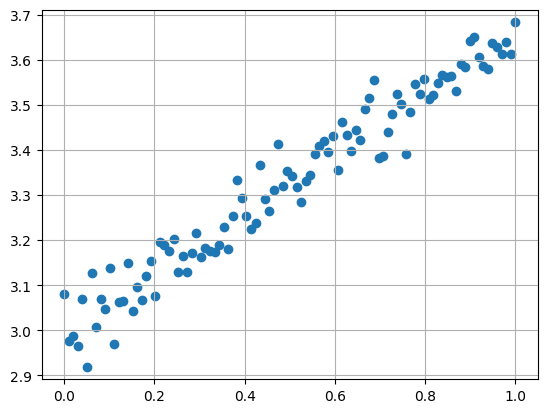

In [12]:
import numpy as np
import matplotlib.pyplot as plt


np.random.seed(1)

N = 100                    # Anzahl Punkte
a, b = 0.65, 3

xi = np.linspace(0,1,N) + 0 * 1e5
yi = a * xi + b + 0.05 * np.random.randn(xi.shape[0])

plt.scatter(xi, yi)
plt.axis("equal")
plt.grid(True)


Konditionszahl von A       =  4.348660714551691
Konditionszahl von A.T @ A =  18.910850010285234


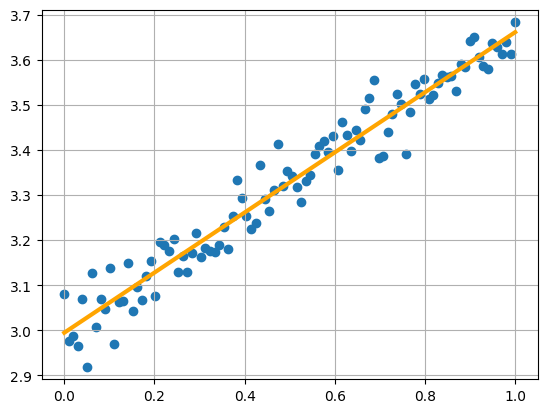

In [13]:

# %% Parameter aus Messungen bestimmen
A = np.array([xi, np.ones_like(xi)]).T

"""
numpy kennt auch den Befehl lstsq (für "least squares")
p, _, _, _ = np.linalg.lstsq(A, y, rcond = None)
Der Befehl gibt nebst dem Parametervektor p weitere Informationen zurück, s. Doku
Lösung mit Normalgleichung:
A.T @ A @ p = A.T @ y

Die Matrix A.T @ A ist positiv definit (solange die Spalten von A l.u. sind) und symmetrisch, also kann die Cholesky
Zerlegung verwendet werden.

p = np.linalg.solve(A.T@A, A.T@yi)
"""
M = A.T @ A

print("Konditionszahl von A       = ", np.linalg.cond(A)) # s. Skript p. 29 für Konditionszahlen von rechteckigen Matrizen
print("Konditionszahl von A.T @ A = ", np.linalg.cond(M))

p = np.linalg.solve(A.T@A, A.T@yi) # Cholesky Zerlegung verwenden!

# %% plot
plt.scatter(xi, yi)
plt.grid(True)
plt.plot(xi, A @ p, linewidth = 3, color = "orange")
plt.axis("equal");

Die Fehlerquadratsumme kann am einfachsten als
$$
    e^2 = |A \vec{p} - \vec{y}|^2
$$
bestimmt werden

In [14]:
print("Fehlerquadratsumme = ", np.linalg.norm(A@p - yi)**2)

Fehlerquadratsumme =  0.1935489334816051


**Nebenbemerkung 1** 
Die Fehlerquadratsumme 

$$
    e^2 = |A \vec{p} - \vec{y}|^2 = \sum_{i=1}^{N} (A \vec{p} - \vec{y})_i^{\,2}
$$

ist die Summe der quadrierten Einzelfehler.

**Nebenbemerkung 2**
Ein gerne verwendetes weiteres Mass ist der sogenannte $R^2$-Score ("R2-Score"), definiert durch

$$
    R^2 = \frac{ \sum (\hat{y}_i - \bar{y})^2}{\sum (y_i - \bar{y})^2}
$$

wobei $y_i$ die Daten sind, die aus dem Modell rekonstruiert werden sollen, $\hat{y}_i = A \cdot \vec{p}$ die rekonstruierten Daten und $\bar{y}$ der Mittelwert der ursprünglichen Daten ist. Der R2-Score ist das Verhältnis der Varianz in den Messdaten und den Ergebnissen des Modells und drückt folglich etwa aus, welcher Anteil der in den Daten vorhandenen Varianz durch das Modell erklärt wird. Der R2-Score liegt für ein brauchbares Modell immer zwischen $0$ und $1$.

In [15]:
ybar = np.mean(yi)
R2 = np.linalg.norm(A@p-ybar)**2 / np.linalg.norm(yi-ybar)**2

print("R2-Score = ", R2)

R2-Score =  0.9512552794286079


## Linearkombination von Modellfunktionen

Lineare Ausgleichsrechnung kann auch verwendet werden, um die Parameter in einer Linearkombination von beliebigen "Basisfunktionen" zu fitten, also z.B. ein Modell der Form
$$
    f(\vec{p}, {\color{gray} X}) = p_1 \cdot f_1(X) + p_2 \cdot f_2(X) + \ldots + p_n \cdot f_n(X)
$$

Beispiel: mit $X = (x_i, y_i)$ 

$$
    y = a + b \cdot \tanh(x) + c \cdot \exp(-x^2)
$$

Die Koeffizientenmatrix $A$ enthält in diesem Fall die Werte der Basisfunktionen an den gegebenen Stellen:

$$
    A = \begin{pmatrix} 
    1 & \tanh(x_1) & \exp(-x_1^2) \\
    1 & \tanh(x_2) & \exp(-x_2^2) \\
      &    \vdots & \\
    1 & \tanh(x_n) & \exp(-x_n^2) 
    \end{pmatrix}
$$




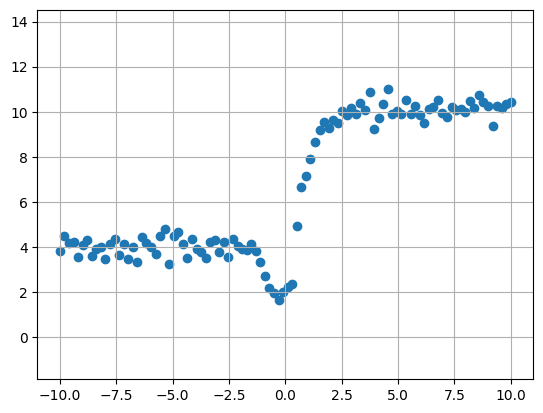

In [16]:
# Testdaten erzeugen 
N = 100                    # Anzahl Punkte
a, b, c = 7, 3, -5         # zufällige Parameter

xi = np.linspace(-10, 10, N)
yi = a + b * np.tanh(xi) + c * np.exp(-xi**2) + 0.4 * np.random.randn(xi.shape[0])

plt.scatter(xi, yi)
plt.axis("equal")
plt.grid(True)

gefundene Parameter:
	a =  7.059856626596009
	b =  3.039298148058836
	c =  -4.98562417071214


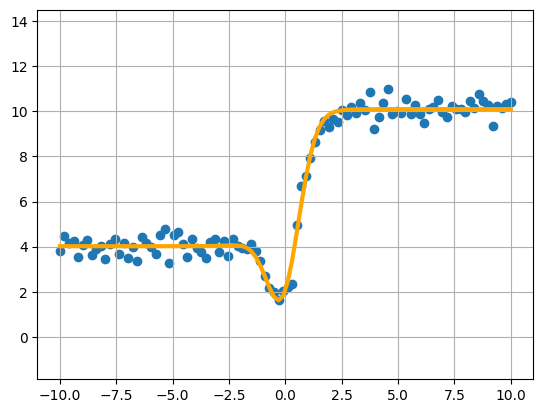

In [17]:

# %% Parameter aus Messungen bestimmen
A = np.array([np.ones_like(xi), np.tanh(xi), np.exp(-xi**2)]).T

p = np.linalg.solve(A.T@A, A.T@yi)

# %% plot
plt.scatter(xi, yi)
plt.grid(True)
plt.plot(xi, A @ p, linewidth = 3, color = "orange")
plt.axis("equal");
print("gefundene Parameter:")
print("\ta = ", p[0])
print("\tb = ", p[1])
print("\tc = ", p[2])

## Tricks
Manchmal lässt sich ein nichtlineares Regressionsproblem durch die Einführung neuer Variablen in ein lineares überführen. Achtung: die Lösung des nichtlinearen Regressionsproblems stimmt in der Regel nicht exakt mit der Lösung des nichtlinearen Regressionsproblems (s. Woche 7) überein. (...und das geht natürlich auch nicht immer.)

### Beispiel 1

Das Regressionsproblem mit $X = (x_i, y_i)$ dem Modell

$$
    y = \frac{1}{a + b x} 
$$

kann durch die neue Variable 

$$
    z = \frac{1}{y}
$$

auf das lineare Problem

$$
    z = a + b x
$$

zurückgeführt werden.

### Beispiel 2
Das Problem, wieder mit $X = (x_i ,y_i)$ und dem Modell

$$
    y = a \cdot e^{b x}
$$

lässt sich durch die neue Variable

$$
    z = \ln y
$$

auf

$$
    z = \ln a + b \cdot x
$$

zurückführen

### Beispiel 3
Das Problem, einen **Ausgleichskreis** zu finden hat die Messdaten $X = (x_i, y_i)$ und das Modell

$$
    (x_i - m_x)^2 + (y_i - m_y)^2 = r^2
$$

mit den Parametern $(m_x, m_y, r)$.

Durch Ausmultiplizieren erhält man

$$
    x_i^2 - 2 m_x x_i + y_i^2 - 2 m_y y_i = r^2 - m_x^2 - m_y^2
$$

Dies ist linear, wenn als Parameter $(m_x, m_y, \rho := r^2 - m_x^2 - m_y^2)$ verwendet werden. In dieser Form lautet es

$$
    \rho + 2 \, x_i \cdot m_x + 2 y_i \cdot m_y = x_i^2 + y_i^2
$$



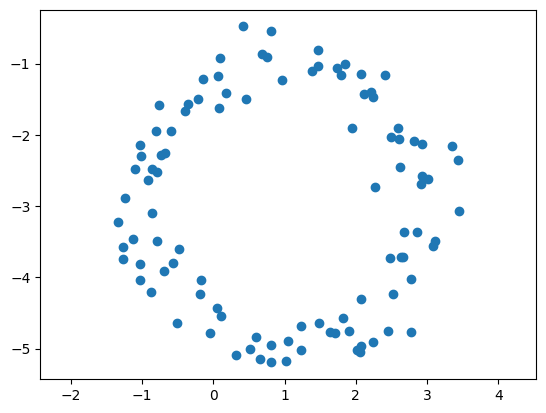

In [18]:
N = 100
a, b = -np.pi, np.pi
phi = np.linspace(a,b,N) 
r, mx, my = 2, 1, -3

xi = mx + r * np.cos(phi) + np.random.randn(N) * 0.25
yi = my + r * np.sin(phi) + np.random.randn(N) * 0.25

plt.scatter(xi, yi)
plt.axis("equal");

gefundene Parameter
r =   2.0300213121403474
mx =  0.9993155671559847
my =  -2.9809515013956696


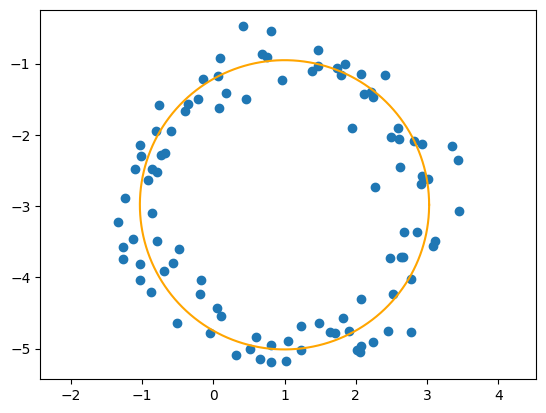

In [19]:
A = np.array([np.ones_like(xi), 2 * xi, 2 * yi]).T
p = np.linalg.solve(A.T@A, A.T @ (xi**2 + yi**2))

rho, mx, my = p
r  = np.sqrt(mx**2 + my**2 + rho)

print("gefundene Parameter")
print("r =  ", r)
print("mx = ", mx)
print("my = ", my)

# Kreis aus geschätzten Parametern rekonstruieren
phi = np.linspace(0, 1, 500) * 2 * np.pi
x = mx + r * np.cos(phi) 
y = my + r * np.sin(phi) 

plt.scatter(xi, yi);
plt.axis("equal");
plt.plot(x, y, color = "orange");